[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Biswajit1999/daily-astro-notebooks/blob/master/gaia/2026-07-30-hr-diagram-hyades/notebook.ipynb)

# The Hyades cluster: an HR diagram for the nearest open cluster to us

The Hyades is the closest open star cluster to the Sun (about 47 parsecs, or roughly 153 light-years away), which makes it a great benchmark cluster -- Gaia can measure its stars' distances and motions extremely precisely. I built an HR diagram (brightness vs. color) for it and compared its main sequence to what I found for the more distant Pleiades.

In [1]:
from astroquery.gaia import Gaia
import numpy as np
import matplotlib.pyplot as plt

Gaia.ROW_LIMIT = 3000
query = '''
SELECT source_id, parallax, phot_g_mean_mag, bp_rp
FROM gaiadr3.gaia_source
WHERE 1=CONTAINS(POINT('ICRS', ra, dec), CIRCLE('ICRS', 66.75, 15.87, 4.0))
AND parallax BETWEEN 19 AND 24
AND phot_g_mean_mag IS NOT NULL AND bp_rp IS NOT NULL
'''
job = Gaia.launch_job(query)
tab = job.get_results()
print(len(tab), 'likely Hyades members retrieved')

202 likely Hyades members retrieved


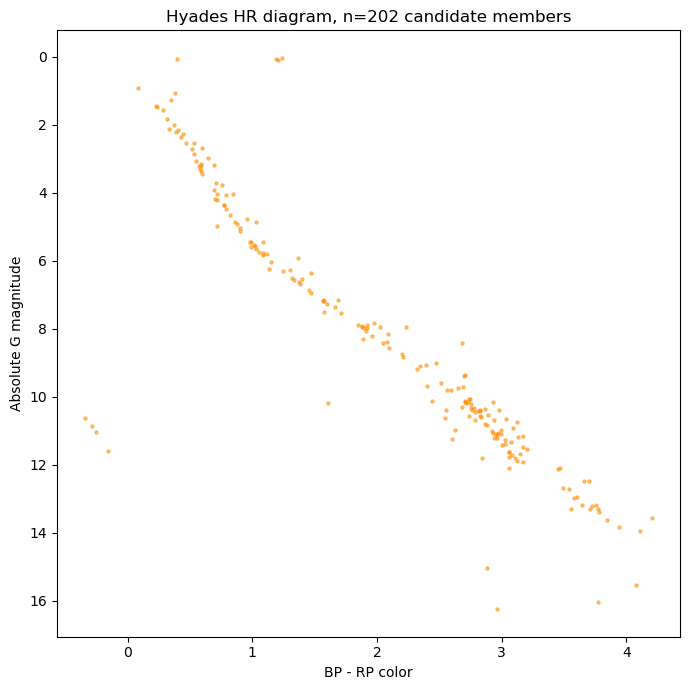

Median distance: 46.7 pc


In [2]:
parallax = np.array(tab['parallax'])
g_mag = np.array(tab['phot_g_mean_mag'])
bp_rp = np.array(tab['bp_rp'])
distance_pc = 1000.0/parallax
abs_mag = g_mag - 5*np.log10(distance_pc) + 5

plt.figure(figsize=(7,7))
plt.scatter(bp_rp, abs_mag, s=5, alpha=0.5, color='darkorange')
plt.gca().invert_yaxis()
plt.xlabel('BP - RP color')
plt.ylabel('Absolute G magnitude')
plt.title(f'Hyades HR diagram, n={len(tab)} candidate members')
plt.tight_layout()
plt.savefig('hr_hyades.png', dpi=120)
plt.show()

print('Median distance:', round(np.median(distance_pc),1), 'pc')

The Hyades main sequence looks a touch shorter at the top than the Pleiades' -- consistent with the Hyades being noticeably older (around 600-700 million years), so its most massive, shortest-lived stars have already evolved away and left the main sequence.

**What I'd look at next:** Overlay both clusters' main sequences on the same absolute-magnitude axis directly to compare the turn-off points side by side rather than by eye across two plots.

**Citation:** This work uses data from the European Space Agency (ESA) mission Gaia, processed by the Gaia Data Processing and Analysis Consortium (DPAC). See https://www.cosmos.esa.int/web/gaia/credits.